# OPeNDAP: large gridded netCDF, sliced server-side

Inversions, emission inventories and model output are multi-gigabyte gridded
netCDF objects. **Do not download them** — open them over OPeNDAP
(`opendap.icos-cp.eu`) and slice first: only the bytes of your subset move.

This route needs the portal token (free
[Carbon Portal account](https://cpauth.icos-cp.eu/); on the ICOS JupyterHub the
credentials are already there). Requirements:
`pip install xarray pydap icoscp_core matplotlib`.

In [1]:
import requests, xarray as xr
from icoscp_core.icos import auth

session = requests.Session()
session.headers.update({"Authorization": "Bearer " + auth.get_token().cookie_value})

OBJECT_ID = "nSEUnW0USDG3ItrwyW1Rjlhk"    # anthropogenic CO2 emissions, per sector
ds = xr.open_dataset(f"dap2://opendap.icos-cp.eu/{OBJECT_ID}",
                     engine="pydap", backend_kwargs={"session": session})
print(dict(ds.sizes))
print("sectors:", list(ds.data_vars))

{'time': 672, 'latitude': 390, 'longitude': 250}
sectors: ['A_Public_power', 'B_Industry', 'C_Other_stationary_combustion_consumer', 'F_On-road', 'H_Aviation', 'I_Off-road', 'G_Shipping', 'cement', 'combustion', 'anthropogenic']


Metadata came back in seconds; the full dataset would be gigabytes.
Always **inspect first, then take only what you need** — here one sector at
one time step (a 390×250 slice, ~0.3 s):

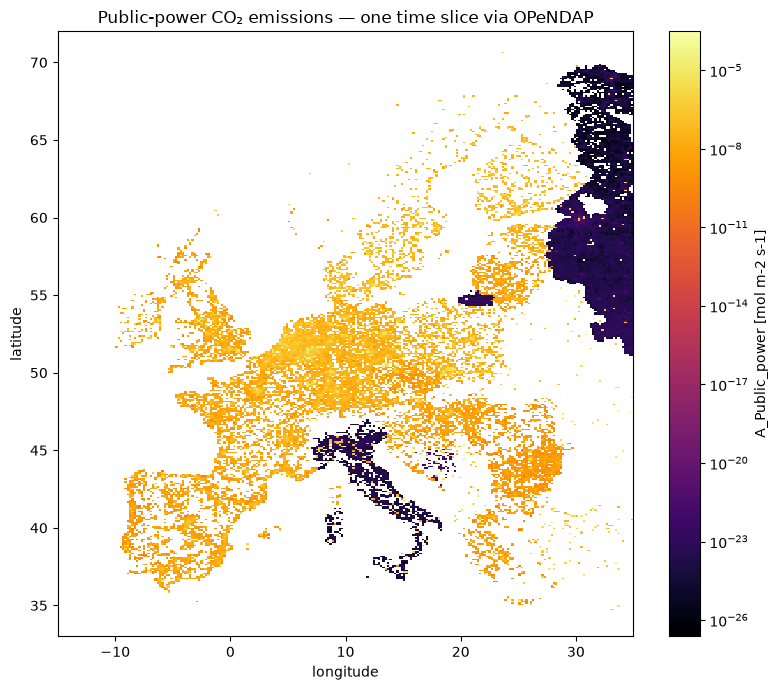

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

v = ds["A_Public_power"]                       # mol m-2 s-1
sl = v.isel(time=0).values
masked = np.ma.masked_where(sl <= 0, sl)

fig, ax = plt.subplots(figsize=(8, 7))
pm = ax.pcolormesh(ds.longitude, ds.latitude, masked,
                   norm=LogNorm(), cmap="inferno")
fig.colorbar(pm, label=f"{v.name} [{v.attrs.get('units', '')}]")
ax.set_title("Public-power CO₂ emissions — one time slice via OPeNDAP")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.tight_layout()

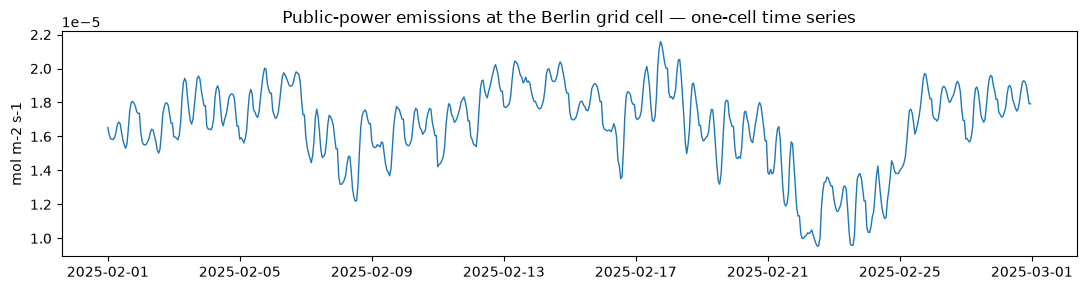

In [3]:
# Server-side subsetting the other way round: the full TIME series of one
# grid cell (Berlin) — 672 values cross the wire, not the whole cube.
import pandas as pd
cell = v.sel(latitude=52.5, longitude=13.4, method="nearest")
s = pd.Series(cell.values, index=pd.to_datetime(ds.time.values))

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(s.index, s.values, lw=1)
ax.set_ylabel(v.attrs.get("units", ""))
ax.set_title("Public-power emissions at the Berlin grid cell — one-cell time series")
fig.tight_layout()

**When NOT to use OPeNDAP**: point time series. The DAP handshake costs
~6 s *per object*, and e.g. ObsPack is one object per station × intake height
× gas — the Zarr store (notebook 02) opens the same series in ~1 s and the
REST API (notebook 03) filters it in one call. OPeNDAP earns its keep when
the alternative is moving gigabytes.